In [2]:
import numpy as np
import pandas as pd
import random

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_excel("clt_practice_dataset.xlsx")
df.head()

,customer_id,household_id,segment,normal_measurement,uniform_value,wait_time_min,churn,segment_score,clustered_score
0,C00001,H0001,B,56.813,32.613,0.244,0,106.438,40.341
1,C00002,H0001,A,63.504,86.067,6.517,1,48.219,42.328
2,C00003,H0001,B,73.264,1.051,1.155,0,84.563,49.132
3,C00004,H0001,B,62.460,43.605,6.625,0,99.280,41.653
4,C00005,H0001,A,66.660,94.284,9.130,0,58.328,49.571


In [4]:
df.shape

(5000, 9)

# Central Limit Theorem

## Populaation `wait_time_min`

In [5]:
pop_wait_time = df['wait_time_min']

In [6]:
pop_wait_time_mean = pop_wait_time.mean()
pop_wait_time_var = pop_wait_time.var(ddof=0)
pop_wait_time_std = pop_wait_time.std(ddof=0)

print(f"Mean: {pop_wait_time_mean}")
print(f"Var: {pop_wait_time_var}")
print(f"Std: {pop_wait_time_std}")

Mean: 7.9744828
Var: 64.64321404010416
Std: 8.040100375001805


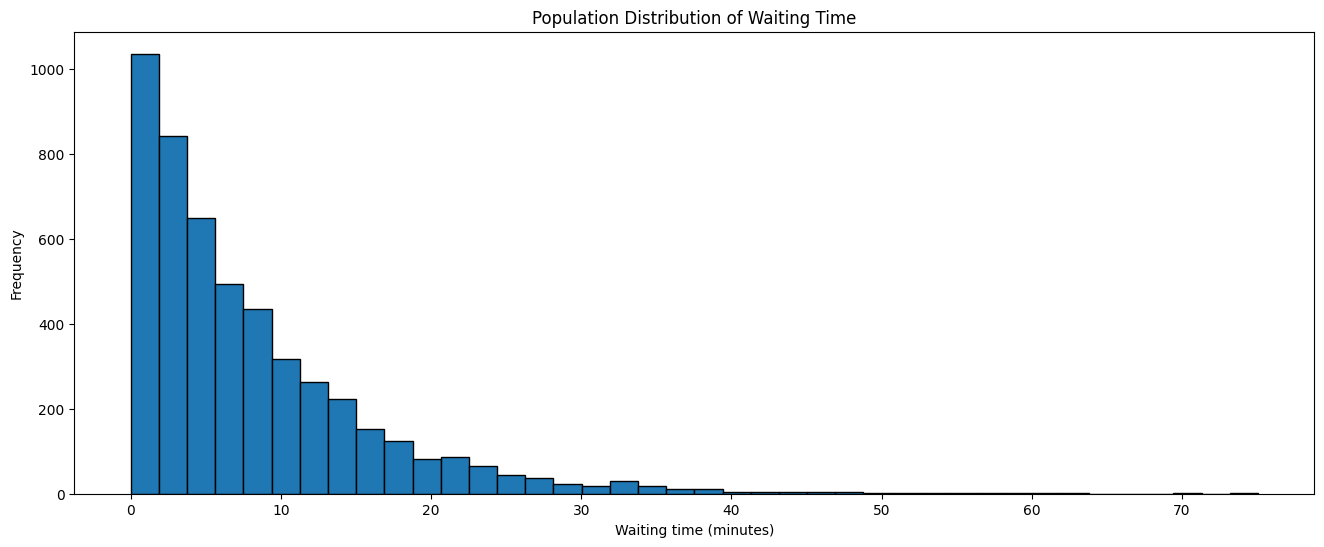

In [7]:
plt.figure(figsize=(16, 6))

plt.hist(pop_wait_time, bins=40, edgecolor="black")
plt.xlabel("Waiting time (minutes)")
plt.ylabel("Frequency")
plt.title("Population Distribution of Waiting Time")
plt.show()

## Sampling

In [8]:
def sampling(population, num_samples=100, n=50):
    results = pd.DataFrame(columns=['sample', 'mean', 'variance', 'std'])
    num_sample = 1

    for i in range(num_samples):
        sampl = population.sample(
            n=n,
            replace=True,
            random_state=42+i
        )

        sampl_mean = sampl.mean()
        sampl_var = sampl.var()
        sampl_std = sampl.std()

        results.loc[len(results)] = [f"{num_sample}-sample", sampl_mean, sampl_var, sampl_std]
        num_sample += 1

    return results

In [9]:
samples_results = sampling(pop_wait_time, num_samples=5000, n=1000)


In [10]:
samples_results.head()

,sample,mean,variance,std
0,1-sample,8.155672,60.006698,7.746399
1,2-sample,8.167023,66.539109,8.157151
2,3-sample,8.275131,70.148773,8.375486
3,4-sample,7.912746,56.323125,7.504873
4,5-sample,8.065268,62.195203,7.886394


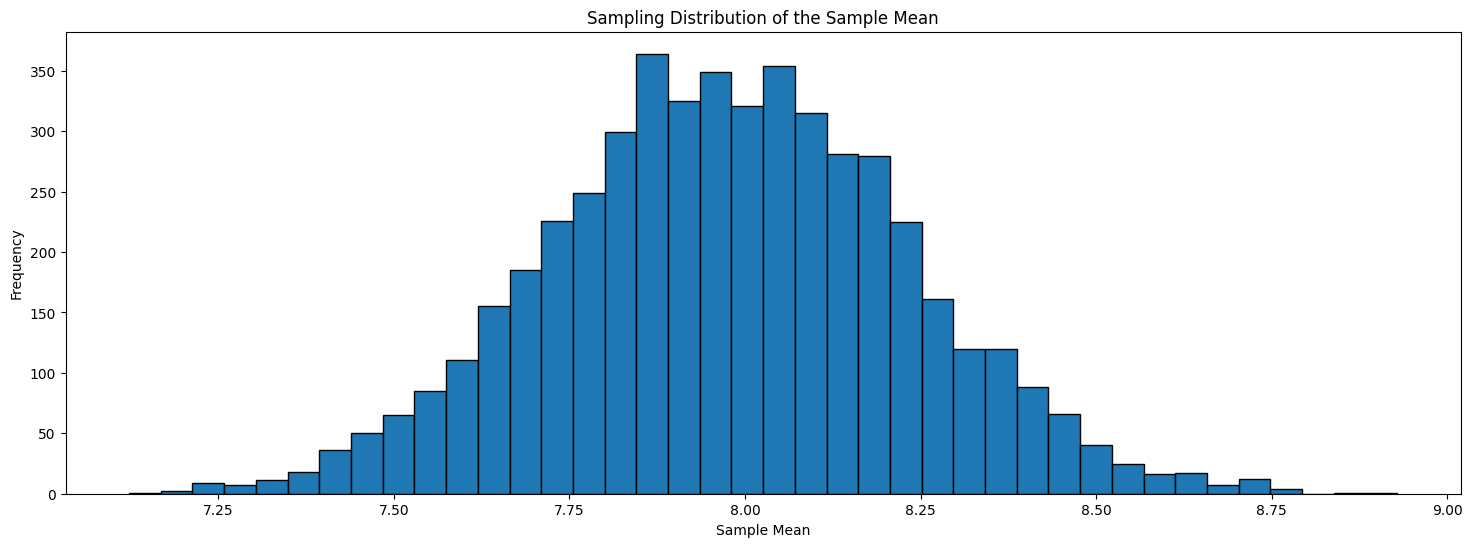

In [11]:
plt.figure(figsize=(18, 6))

plt.hist(
    samples_results['mean'],
    bins=40,
    edgecolor="black"
)
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.title("Sampling Distribution of the Sample Mean")
plt.show()

## Mathematical Structure of CLT

### Expected Value of Sample Mean

`E[X̄] = μ` it means that the expected value of samples' means equal to population mean

In [12]:
pop_wait_time_mean = df['wait_time_min'].mean()
pop_wait_time_mean

np.float64(7.9744828)

In [13]:
sample_mean_expected_value = samples_results['mean'].mean()
sample_mean_expected_value

np.float64(7.9770572206)

### Variance of Sample Mean

`Var(X̄) = σ² / n` 

In [14]:
pop_wait_time_var = df['wait_time_min'].var()
pop_wait_time_var

np.float64(64.65614526915799)

In [15]:
n = 1000
sample_mean_variance = pop_wait_time_var / n
sample_mean_variance

np.float64(0.06465614526915799)

In [16]:
ordinary_sample_mean_variance = samples_results['mean'].var()
ordinary_sample_mean_variance

np.float64(0.06500369362872767)

### Standard deviation of sample mean

`Std(X̄) = σ / √n`

In [17]:
pop_wait_time_std = df['wait_time_min'].std(ddof=0)
pop_wait_time_std

np.float64(8.040100375001805)

In [18]:
n

1000

In [19]:
sample_mean_std = pop_wait_time_std / np.sqrt(n)
sample_mean_std

np.float64(0.25425029801379617)

In [20]:
ordinary_sample_mean_std = samples_results['mean'].std(ddof=0)
ordinary_sample_mean_std

np.float64(0.2549327222817854)

### Standard Error

`SE(X̄) = σ / √n`

In [21]:
sample_standard_error = pop_wait_time_std / np.sqrt(n)
sample_standard_error

np.float64(0.25425029801379617)

## Assumptions

### Random Sampling

In [22]:
pop_wait_time.describe()

count    5000.000000
mean        7.974483
std         8.040905
min         0.001000
25%         2.280000
50%         5.544500
75%        11.078500
max        75.076000
Name: wait_time_min, dtype: float64

In [23]:
n = 1000
random_sample = pop_wait_time.sample(
    n=n,
    replace=False,
    random_state=42
)
random_sample.describe()

count    1000.000000
mean        7.854356
std         7.813415
min         0.004000
25%         2.317000
50%         5.482500
75%        10.884250
max        51.049000
Name: wait_time_min, dtype: float64

In [24]:
biased_population = df[
    df['wait_time_min'] > df['wait_time_min'].quantile(0.80)
]

biased_sample = biased_population['wait_time_min'].sample(
    n=n,
    replace=True,
    random_state=42
)

biased_sample.describe()

count    1000.000000
mean       20.871122
std         8.226830
min        12.777000
25%        14.896000
50%        18.427000
75%        23.335250
max        75.076000
Name: wait_time_min, dtype: float64

### Independence of Observations

In [25]:
df.head()

,customer_id,household_id,segment,normal_measurement,uniform_value,wait_time_min,churn,segment_score,clustered_score
0,C00001,H0001,B,56.813,32.613,0.244,0,106.438,40.341
1,C00002,H0001,A,63.504,86.067,6.517,1,48.219,42.328
2,C00003,H0001,B,73.264,1.051,1.155,0,84.563,49.132
3,C00004,H0001,B,62.460,43.605,6.625,0,99.280,41.653
4,C00005,H0001,A,66.660,94.284,9.130,0,58.328,49.571


looking at one household

In [26]:
df[
    df['household_id'] == 'H0001'
][['household_id', 'clustered_score']]

,household_id,clustered_score
0,H0001,40.341
1,H0001,42.328
2,H0001,49.132
3,H0001,41.653
4,H0001,49.571


these observations are dependent, because they share the same underlying household effect.

In [27]:
df.groupby(by='household_id').first()['clustered_score'].head(5)

household_id
H0001    40.341
H0002    67.212
H0003    52.449
H0004    47.615
H0005    55.127
Name: clustered_score, dtype: float64

now each observation comes from a different household, so clustered-scores are very different, these observations are independent

creating a more independent sample

In [28]:
independent_sample = (
    df.groupby(by='household_id') # grouping by household_id
    .sample(n=1,random_state=42) # taking 1 random sample from each household_id 
    .sample(n=100, random_state=42) # choose only 100 from all those one-person-per-household observations
)

independent_sample[['household_id', 'clustered_score']].head(10)

,household_id,clustered_score
2605,H0522,56.392
3686,H0738,51.576
3704,H0741,69.979
3303,H0661,51.701
2057,H0412,40.835
3394,H0679,41.550
3132,H0627,61.407
2567,H0514,38.263
4296,H0860,55.479
684,H0137,53.529


In [29]:
independent_sample['household_id'].nunique()

100

100 observations come from 100 different households

### Identically Distributed Observations

In [30]:
df.head()

,customer_id,household_id,segment,normal_measurement,uniform_value,wait_time_min,churn,segment_score,clustered_score
0,C00001,H0001,B,56.813,32.613,0.244,0,106.438,40.341
1,C00002,H0001,A,63.504,86.067,6.517,1,48.219,42.328
2,C00003,H0001,B,73.264,1.051,1.155,0,84.563,49.132
3,C00004,H0001,B,62.460,43.605,6.625,0,99.280,41.653
4,C00005,H0001,A,66.660,94.284,9.130,0,58.328,49.571


In [31]:
df.groupby(by='segment')['segment_score'].agg(
    ['mean', 'var', 'std', 'count']
)

,mean,var,std,count
segment,,,,
A,60.149589,65.986887,8.123231,3049
B,90.146054,65.303090,8.081033,1951


these two groups A and B have different underlying means

#### Identically distributed example

In [32]:
segment_A = df[
    df['segment'] == 'A'
]['segment_score']

sample_A = segment_A.sample(
    n=100,
    replace=True,
    random_state=42
)
sample_A.describe()

count    100.000000
mean      61.833900
std        8.061317
min       46.624000
25%       56.319500
50%       60.742000
75%       66.215500
max       86.444000
Name: segment_score, dtype: float64

all 100 random variables come from the same underlying distribution. These values are different but 
- E[X1] = E[X2] = ... = 60.1  because population mean=60.1
- Std(X1) = Std(X2) = ... = 8.1 because population std=8.1

#### Not Identically Distributed case

In [33]:
Sample_1 = (
    df[df['segment'] == 'A']['segment_score']
    .sample(
        n=50,
        replace=True,
        random_state=42
    )
)

Sample_2 = (
    df[df['segment'] == 'B']['segment_score']
    .sample(
        n=50,
        replace=True,
        random_state=42
    )
)

print(Sample_1.describe())
print("------------")
print(Sample_2.describe())

count    50.000000
mean     63.654460
std       8.730726
min      46.971000
25%      57.578500
50%      61.563500
75%      69.859500
max      86.444000
Name: segment_score, dtype: float64
------------
count     50.000000
mean      90.490440
std        8.919779
min       64.106000
25%       85.080500
50%       92.028500
75%       96.782750
max      106.958000
Name: segment_score, dtype: float64


Now
- Sample_1 comes from different Distribution: Population-stats: mean=60.1, Var=65.9, Std=8.1
- Sample_2 comes from different Distribution: Population-stats: mean=90.1, Var=65.3, Std=8.0


Identically distributed observations means that every observation is generated from the same underlying probability distribution, with the same population parameters such as mean and variance. The observed values themselves do not need to be equal.

### Finite Mean and Finite Variance

In [34]:
pop_wait_time = df['wait_time_min']

population_mean = pop_wait_time.mean()
population_variance = pop_wait_time.var(ddof=0)

print("Mean:", population_mean)
print("Variance:", population_variance)

Mean: 7.9744828
Variance: 64.64321404010416


so this condition is satisfied.
- μ < 7.97 -> μ < ∞
- σ² < 64.6 ->σ² < ∞


### Sufficiently Large Sample Size

In [35]:
df.head()

,customer_id,household_id,segment,normal_measurement,uniform_value,wait_time_min,churn,segment_score,clustered_score
0,C00001,H0001,B,56.813,32.613,0.244,0,106.438,40.341
1,C00002,H0001,A,63.504,86.067,6.517,1,48.219,42.328
2,C00003,H0001,B,73.264,1.051,1.155,0,84.563,49.132
3,C00004,H0001,B,62.460,43.605,6.625,0,99.280,41.653
4,C00005,H0001,A,66.660,94.284,9.130,0,58.328,49.571


#### Population Distribution

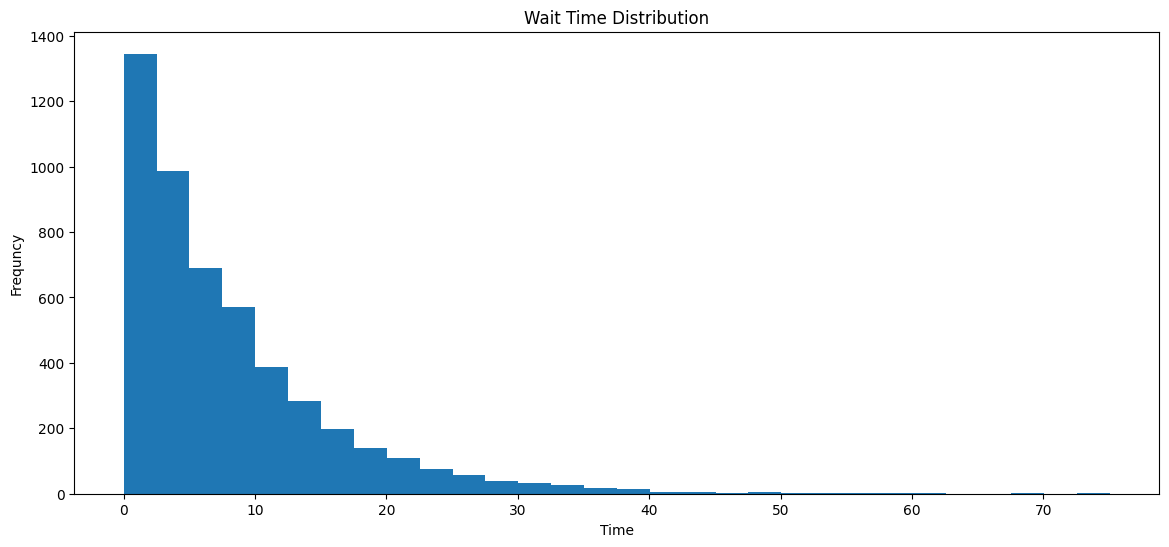

In [39]:
plt.figure(figsize=(14, 6))

plt.hist(df['wait_time_min'], bins=30)
plt.title("Wait Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequncy")
plt.show()

#### Different sample size distributions

In [66]:
sample_n2_stats = sampling(df['wait_time_min'], num_samples=1000, n=2)
sample_n10_stats = sampling(df['wait_time_min'], num_samples=1000, n=10)
sample_n100_stats = sampling(df['wait_time_min'], num_samples=1000, n=100)
sample_n500_stats = sampling(df['wait_time_min'], num_samples=1000, n=500)

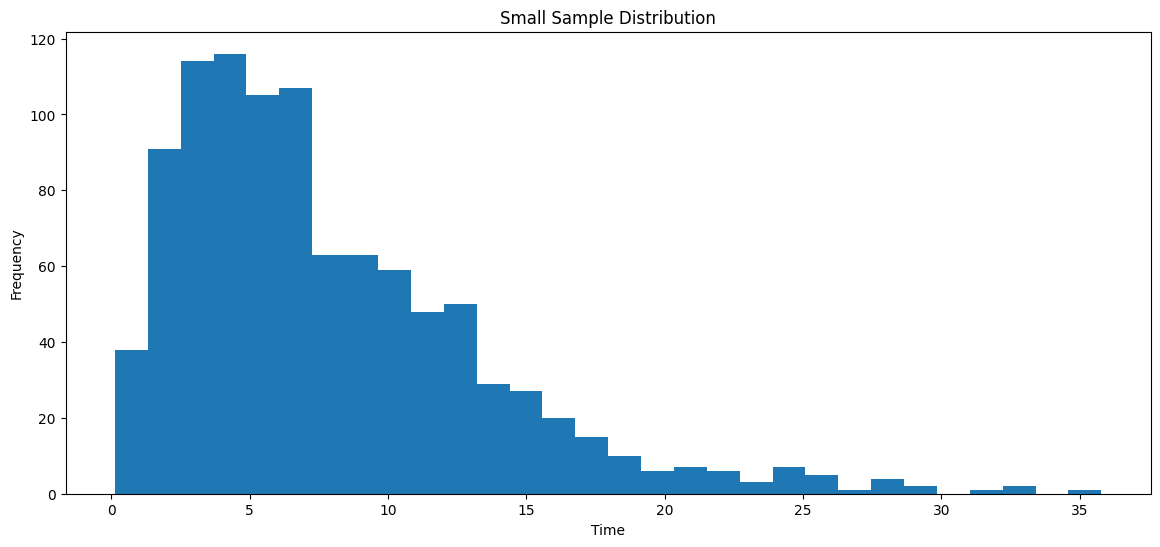

In [67]:
plt.figure(figsize=(14, 6))
plt.hist(
    sample_n2_stats['mean'],
    30
)
plt.title("Small Sample Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

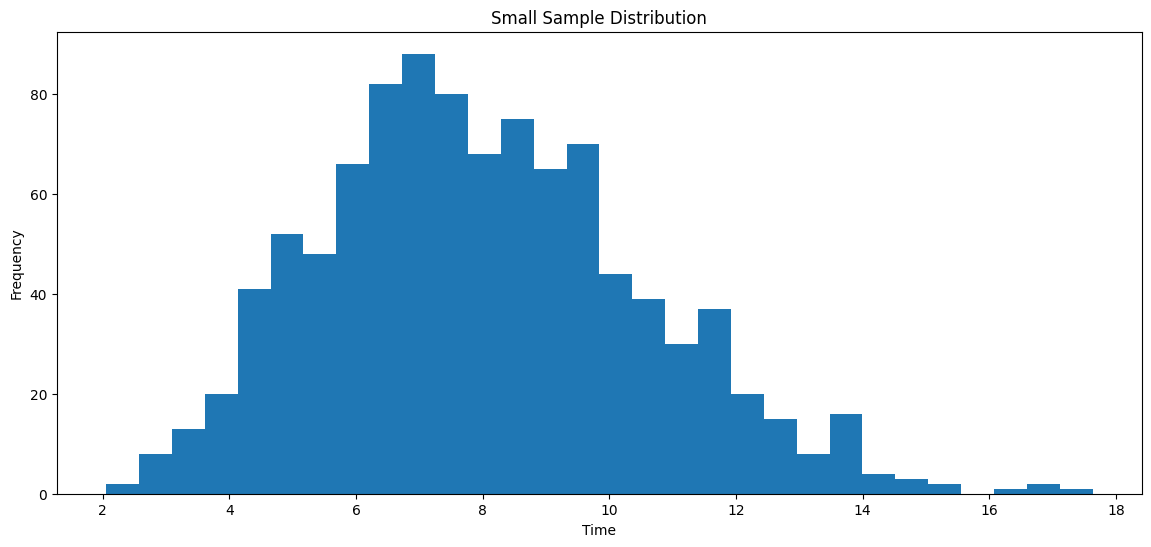

In [68]:
plt.figure(figsize=(14, 6))
plt.hist(
    sample_n10_stats['mean'],
    30
)
plt.title("Small Sample Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

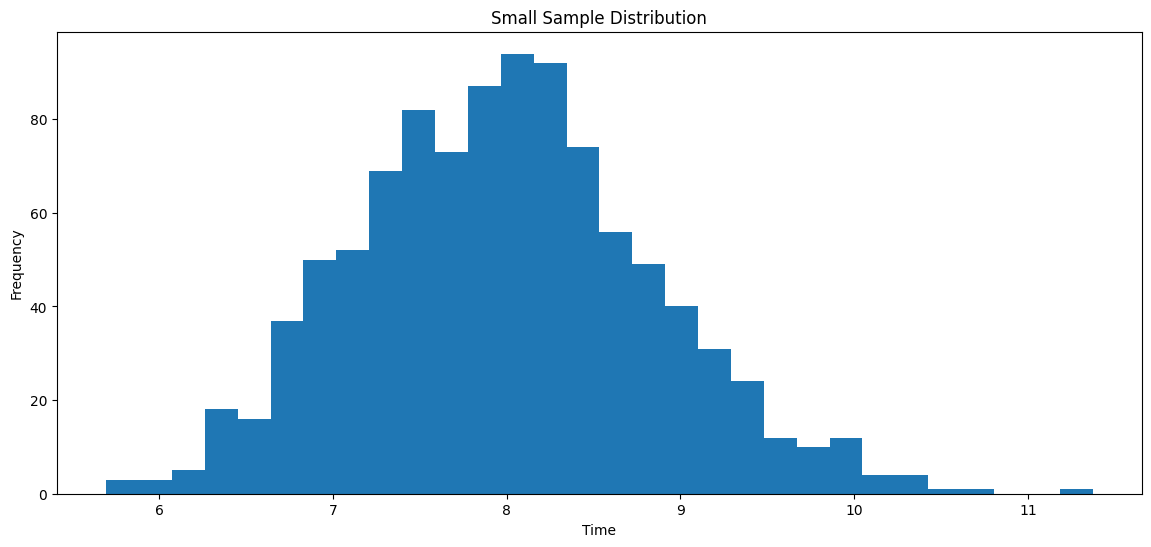

In [69]:
plt.figure(figsize=(14, 6))
plt.hist(
    sample_n100_stats['mean'],
    30
)
plt.title("Small Sample Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

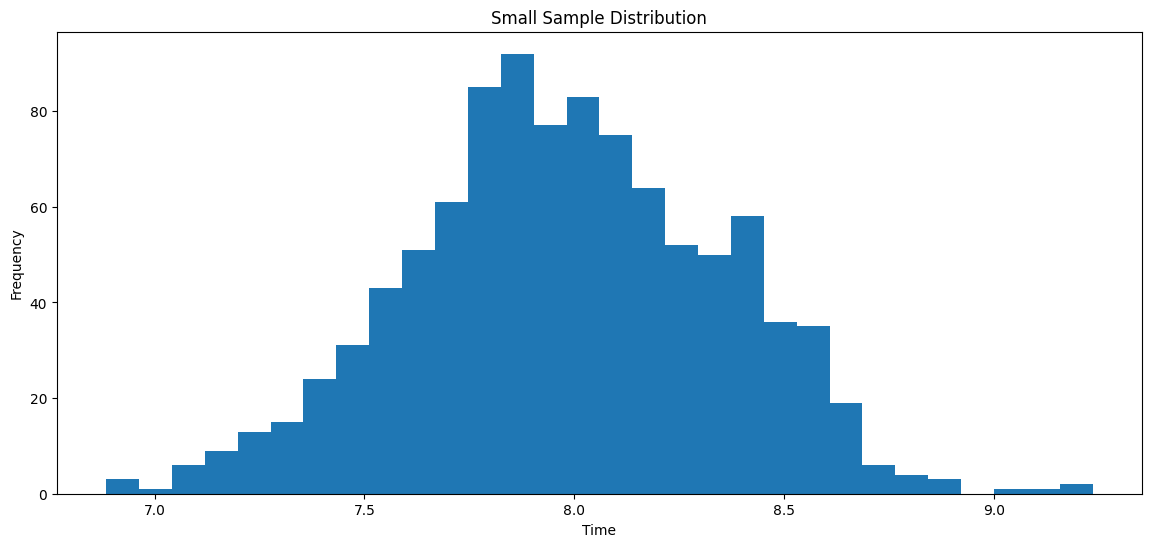

In [70]:
plt.figure(figsize=(14, 6))
plt.hist(
    sample_n500_stats['mean'],
    30
)
plt.title("Small Sample Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

## CLT with differet population distributions

In [72]:
df.head()

,customer_id,household_id,segment,normal_measurement,uniform_value,wait_time_min,churn,segment_score,clustered_score
0,C00001,H0001,B,56.813,32.613,0.244,0,106.438,40.341
1,C00002,H0001,A,63.504,86.067,6.517,1,48.219,42.328
2,C00003,H0001,B,73.264,1.051,1.155,0,84.563,49.132
3,C00004,H0001,B,62.460,43.605,6.625,0,99.280,41.653
4,C00005,H0001,A,66.660,94.284,9.130,0,58.328,49.571


##  Standardization Using CLT

`Z = (X̄ - μ) / (σ /√n)`

In [73]:
df.head()

,customer_id,household_id,segment,normal_measurement,uniform_value,wait_time_min,churn,segment_score,clustered_score
0,C00001,H0001,B,56.813,32.613,0.244,0,106.438,40.341
1,C00002,H0001,A,63.504,86.067,6.517,1,48.219,42.328
2,C00003,H0001,B,73.264,1.051,1.155,0,84.563,49.132
3,C00004,H0001,B,62.460,43.605,6.625,0,99.280,41.653
4,C00005,H0001,A,66.660,94.284,9.130,0,58.328,49.571


In [78]:
population = df['wait_time_min']

pop_mean = population.mean()
pop_std = population.std()

In [79]:
n = 500

sample_stats = sampling(population, n=n)
sample_stats.head()

,sample,mean,variance,std
0,1-sample,7.988794,62.531981,7.907717
1,2-sample,8.318322,64.770753,8.048028
2,3-sample,8.014110,72.526122,8.516227
3,4-sample,8.211968,55.668972,7.461164
4,5-sample,8.214488,58.341115,7.638136


In [80]:
sample_mean = sample_stats['mean']
sample_mean.describe()

count    100.000000
mean       7.945490
std        0.325505
min        7.193644
25%        7.735881
50%        7.960352
75%        8.169781
max        8.623234
Name: mean, dtype: float64

In [82]:
def CLT_z_score_stan(sample_mean, pop_mean, pop_std, sample_size):
    return (sample_mean - pop_mean) / (pop_std / np.sqrt(sample_size))

In [84]:
sample_mean_standardized = CLT_z_score_stan(sample_mean, pop_mean, pop_std, n)
sample_mean_standardized.describe()

count    100.000000
mean      -0.080626
std        0.905186
min       -2.171408
25%       -0.663518
50%       -0.039296
75%        0.543098
max        1.804090
Name: mean, dtype: float64

## CLT for Sums

In [92]:
population = df['wait_time_min']

pop_mean = population.mean()
pop_var = population.var()
pop_std = population.std()

In [93]:
def sampling(population, num_samples=100, n=50):
    results = pd.DataFrame(columns=['sample', 'sum', 'mean', 'variance', 'std'])

    for i in range(num_samples):
        sample = population.sample(
            n=n,
            replace=True,
            random_state=42+i
        )

        sample_sum = sample.sum()
        sample_mean = sample.mean()
        sample_var = sample.var()
        sample_std = sample.std()

        results.loc[len(results)] = [
            f"{i+1}-sample",
            sample_sum,
            sample_mean,
            sample_var,
            sample_std
        ]

    return results

In [94]:
n = 50
sample_stats = sampling(population, num_samples=100, n=n)

In [95]:
sample_stats.head()

,sample,sum,mean,variance,std
0,1-sample,401.046,8.02092,47.924895,6.922781
1,2-sample,485.607,9.71214,77.161759,8.784177
2,3-sample,413.697,8.27394,118.229856,10.873355
3,4-sample,452.311,9.04622,74.653152,8.640206
4,5-sample,368.763,7.37526,30.092296,5.485645


### Sample Sum Mean

In [96]:
expirical_sum_mean = sample_stats['sum'].mean()
theoretical_sum_mean = n * pop_mean

print(expirical_sum_mean)
print(theoretical_sum_mean)

400.13526999999993
398.72414


### Sample Sum Variance

In [97]:
empirical_sum_var = sample_stats['sum'].var()

theoretical_sum_var = n * (pop_std ** 2)

print(empirical_sum_var)
print(theoretical_sum_var)

3559.4592659162627
3232.807263457899


### Sample Sum Standard Deviation

In [98]:
empirical_sum_std = sample_stats['sum'].std()

theoretical_sum_std = pop_std * np.sqrt(n)

print(empirical_sum_std)
print(theoretical_sum_std)

59.66120402670619
56.857781028262956
